In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


data = load_breast_cancer()
X = data.data
y = data.target

print(f'dataset shape :{X.shape}')
print(f"Class distribution: {np.bincount(y)}")
print(f"Feature names: {data.feature_names[:5]}...")


dataset shape :(569, 30)
Class distribution: [212 357]
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...


In [2]:
def normalize(X): 
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean) / std, mean, std

X_norm, X_mean, X_std = normalize(X)

print(f"Before normalization — mean: {X[:,0].mean():.2f}, std: {X[:,0].std():.2f}")
print(f"After normalization  — mean: {X_norm[:,0].mean():.2f}, std: {X_norm[:,0].std():.2f}")

Before normalization — mean: 14.13, std: 3.52
After normalization  — mean: -0.00, std: 1.00


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

print(f'train: {X_train.shape}, test: {X_test.shape}')

train: (455, 30), test: (114, 30)


In [4]:
np.random.seed(42)
n_features = X_train.shape[1]
w = np.zeros(n_features)
b = 0.0

print(f"Weight vector shape: {w.shape}")

Weight vector shape: (30,)


In [5]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def predict_proba(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(X, y_true, y_pred):
    n = len(y_true)
    error = y_pred - y_true
    dw = (1/n) * X.T @ error
    db = (1/n) * np.sum(error)
    return dw, db

def predict(X, w, b, threshold=0.5):
    proba = predict_proba(X, w, b)
    return (proba >= threshold).astype(int)

In [6]:
learning_rate = 0.01
epochs = 200
loss_history = []

for epoch in range(epochs):
    
    y_pred = predict_proba(X_train, w, b)

    # compute loss
    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)

    # compute gradients
    dw, db = compute_gradients(X_train, y_train, y_pred)

    # update weights
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if (epoch + 1) % 20 == 0:
        train_acc = np.mean(predict(X_train, w, b) == y_train)
        print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

Epoch  20 | Loss: 0.4652 | Train Acc: 0.9297
Epoch  40 | Loss: 0.3664 | Train Acc: 0.9341
Epoch  60 | Loss: 0.3125 | Train Acc: 0.9473
Epoch  80 | Loss: 0.2778 | Train Acc: 0.9516
Epoch 100 | Loss: 0.2533 | Train Acc: 0.9560
Epoch 120 | Loss: 0.2347 | Train Acc: 0.9582
Epoch 140 | Loss: 0.2201 | Train Acc: 0.9582
Epoch 160 | Loss: 0.2083 | Train Acc: 0.9604
Epoch 180 | Loss: 0.1984 | Train Acc: 0.9626
Epoch 200 | Loss: 0.1900 | Train Acc: 0.9648


In [ ]:
y_test_pred = predict(X_test, w, b)

# accuracy
accuracy = np.mean(y_test_pred == y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp, tn, fp, fn

tp, tn, fp, fn = confusion_matrix_manual(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Positives  (correctly predicted disease):  {tp}")
print(f"  True Negatives  (correctly predicted healthy):  {tn}")
print(f"  False Positives (predicted disease, was healthy): {fp}")
print(f"  False Negatives (predicted healthy, was disease): {fn}")

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * (precision * recall) / (precision + recall)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Test Accuracy: 0.9825

Confusion Matrix:
  True Positives  (correctly predicted disease):  70
  True Negatives  (correctly predicted healthy):  42
  False Positives (predicted disease, was healthy): 1
  False Negatives (predicted healthy, was disease): 1

Precision: 0.9859
Recall:    0.9859
F1 Score:  0.9859


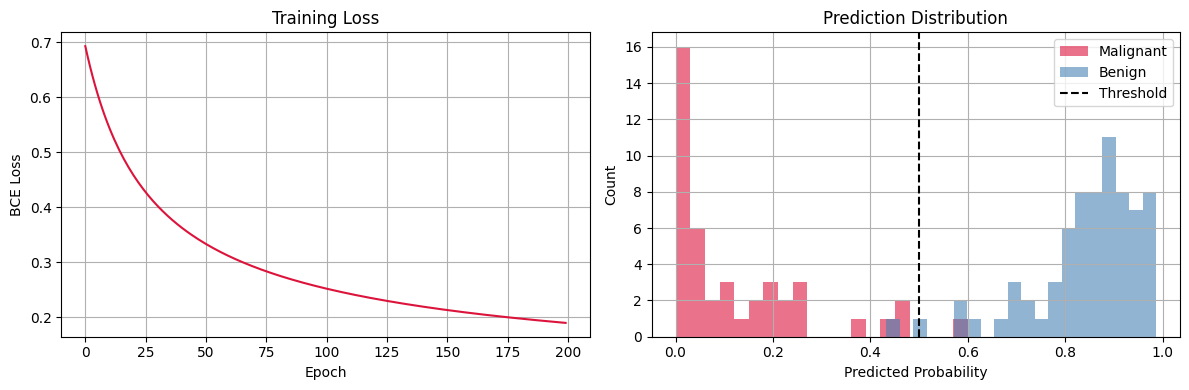

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color='crimson')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
proba = predict_proba(X_test, w, b)
plt.hist(proba[y_test == 0], bins=20, alpha=0.6, color='crimson', label='Malignant')
plt.hist(proba[y_test == 1], bins=20, alpha=0.6, color='steelblue', label='Benign')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Prediction Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()